# 01 CNN Baseline — Fashion-MNIST

このNotebookでは、**Fashion-MNIST + CNN の非圧縮baseline**を作る。

次のSVD実験では、このCNNの後段にある `Linear` 層を最初の圧縮対象にする。

```text
Input: 1 × 28 × 28
    ↓
Conv2d(1, 32, 3, padding=1)
ReLU
MaxPool2d(2)
    ↓
32 × 14 × 14
    ↓
Conv2d(32, 64, 3, padding=1)
ReLU
MaxPool2d(2)
    ↓
64 × 7 × 7
    ↓
Flatten
    ↓
Linear(3136, 128)   ← 次Notebookで最初にSVD
ReLU
    ↓
Linear(128, 10)
```

## このNotebookで自分で理解する部分

CNNをゼロから全部書く必要はない。  
今回は特に次を確認する。

1. `Conv2d` の引数
2. 畳み込み後のshape
3. `MaxPool2d` 後のshape
4. `Flatten` 後がなぜ `3136` になるか
5. `forward()` でテンソルがどう流れるか

学習ループ・評価・checkpoint保存などの定型処理は完成形を用意してある。


In [64]:
# 標準ライブラリ
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import json
import platform
import random
import sys

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ============================================================
# 【.py側をimport】元の03ではここに def / class を書いていた
# ============================================================
# SVD圧縮: 元03では SVD / devidetwolayer（現 factorize_linear_layer）/
# make_two_layer_svd_model をセル定義
from nn_compression.compression import (
    make_two_layer_svd_model,  # compression/mlp_svd.py（MLPの層置換）
    retained_energy,           # compression/svd.py（特異値エネルギー）
)

# データ準備: 元03では FashionMNIST / random_split / DataLoader を直書き
from nn_compression.datasets import (
    get_fashion_mnist_datasets,      # datasets/fashion_mnist.py
    make_fashion_mnist_loaders,      # 同上
    split_fashion_mnist_dataset,     # 同上
)

# 評価指標: 元03では各セルで def していた
from nn_compression.metrics import (
    estimate_mlp_macs,       # metrics/mlp_macs.py（784→512→256前提）
    accuracy_drop,           # metrics/model_comparison.py
    agreement,               # metrics/model_comparison.py
    benchmark_inference,     # metrics/model_comparison.py
    count_parameters,        # metrics/model_comparison.py
    logits_rmse,             # metrics/model_comparison.py
    parameters_reduction,    # metrics/model_comparison.py
)

# モデル: 元03では class MNISTMLP(nn.Module): をNotebook内に書いていた
from nn_compression.models import MNISTMLP  # models/mlp.py

# Pareto / knee: 元03では GetPoint などをセル定義していた
# .py化に合わせて、Python標準の snake_case 名へ整理している
from nn_compression.selection import (
    extract_pareto_frontier, # selection/pareto.py
    find_knee_point,         # selection/knee.py
    get_first_point,         # selection/knee.py
    line_equation,           # selection/knee.py
)

# 学習: 元03では train_one_epoch / evaluate / Early Stoppingループを直書き
from nn_compression.training import (
    evaluate,                 # training/loops.py
    train_one_epoch,          # training/loops.py
    fit_with_early_stopping,  # training/fit.py（Early Stopping付き学習）
)

# パス・seed: 元03では find_project_root / set_seed をNotebook内に定義
from nn_compression.utils import (
    find_project_root,     # utils/paths.py
    get_experiment_dirs,   # utils/paths.py
    make_torch_generator,  # utils/seed.py
    set_seed,              # utils/seed.py
)

## 1. 再現性と実行デバイス

前回のFashion-MNIST実験と比較しやすくするため、seedを固定する。

ここはCNN固有ではないので完成形。


In [65]:
# 再現性のため seed を固定する。MLP実験と同じ 0 にして比較しやすくする。
SEED = 0
# 【.py】utils/seed.py。Python / NumPy / PyTorch の乱数源をまとめて固定する
set_seed(SEED)

# 使えるハードウェアを優先順に選ぶ: CUDA GPU → Apple MPS → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 2. 保存先

MLP実験と同じく、プロジェクトルート基準で分けます。

- データ: `data/`
- 重み: `models/10_svd/30_fashion_mnist_cnn/01_cnn_baseline/`
- CSV・図・metadata: `results/10_svd/30_fashion_mnist_cnn/01_cnn_baseline/`


In [ ]:
# MLP実験と同じく、プロジェクトルート基準で保存先を決める
# Path(".") だと Notebook の cwd 次第で data/results がズレる
# method-first の新しい構成に合わせて保存先を識別する。
METHOD_NAME = "10_svd"
CASE_NAME = "30_fashion_mnist_cnn"
EXPERIMENT_NAME = "01_cnn_baseline"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    METHOD_NAME,
    CASE_NAME,
    EXPERIMENT_NAME,
)

# このNotebook内の既存変数名に合わせる
# 重み → models/..., CSV・図・metadata → results/...
checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


## 3. Fashion-MNISTの読み込み

前回と同じく、

- train: 55,000
- validation: 5,000
- test: 10,000

に分ける。

`ToTensor()` 後の画像shapeは

```text
(C, H, W) = (1, 28, 28)
```

になる。


In [67]:
# 画像をPyTorchで扱える torch.Tensor に変換するための変換処理オブジェクトを作っています。
# Datasetに渡すと、各画像を取り出すたびにこの変換が適用されます。
# ToTensor(): PIL Image (28×28) → Tensor (1, 28, 28)、値域は [0, 1]
transform = transforms.ToTensor()

# 【.py】get_experiment_dirs が返した data/ を使う（cwd に依存しない）
data_root = data_dir

# train=True: 公式の学習用 60,000 枚。後で train / validation に分割する
full_train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

# train=False: 公式のテスト 10,000 枚。最終評価まで使わない
test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

train_size = 55_000
validation_size = 5_000

# random_split の分割結果を seed で固定する
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    lengths=[train_size, validation_size],
    generator=split_generator,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation: {len(validation_dataset):,}")
print(f"test:       {len(test_dataset):,}")


train:      55,000
validation: 5,000
test:       10,000


## 4. DataLoader

batch sizeは前回と同じ `256`。

Windows + Notebookで扱いやすいように `num_workers=0` とする。


In [68]:
BATCH_SIZE = 256
# データを読む・画像変換する・バッチ化するための子プロセス数です。
#0：メインプロセス自身がデータを読み込む。デバッグしやすく、Windows/Jupyterで問題を切り分けやすい
#1 以上：複数の子プロセスが次のバッチを並列に準備するため、ディスクI/Oや画像拡張が重い場合に学習待ち時間を減らせる
#増やしすぎると、CPU競合・メモリ使用量増加・プロセス起動のオーバーヘッドで、かえって遅くなることがある
#num_workers はGPU数ではなく、CPU側のデータ準備担当者の人数です。
# まず 0 で正しく動作を確認し、2, 4, 8 などを実測して、1 epochあたりの時間が最短になる値を選ぶのが確実です。
NUM_WORKERS = 0

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers は、DataLoaderがデータを読み込み・前処理・バッチ化するために使う子プロセスの数です。
    # 大きくすると、次のバッチを並列に準備できるため、GPUがデータ待ちになる時間を減らせる場合があります。
    num_workers=NUM_WORKERS,
    # CUDA GPUを使うときだけ True にする設定です。
    # True なら、DataLoaderが返すCPUテンソルをページロック（pinned）メモリに置き、
    # CPUからGPUへの転送を速くしやすくします。
    # CPU側の転送用メモリを固定する設定です。
    # 小さなデータやCPU学習では効果が乏しく、ホストメモリの負担もあるため、CUDA時だけ有効にする現在の書き方がよいです。
    pin_memory=(device.type == "cuda"),
    # shuffle=True で使うランダムなデータ順序を制御する torch.Generator です。
    # 通常は再現性のためにシード固定済みのジェネレータを渡します。
    generator=loader_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loader を next(iter(...)) すると shuffle 用 Generator を消費するので避ける
image, label = train_dataset[0]
print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(f"batch images shape: ({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})")


image shape: (1, 28, 28)
label: 6
batch images shape: (256, 1, 28, 28)


### 確認問題

上で確認した1枚の画像shapeから、DataLoaderが返す1バッチのshapeを考えてみる。

ヒント：

- 1枚の画像に対して、バッチ化すると何の次元が追加されるか。
- `BATCH_SIZE` と `image.shape` を見比べる。


## 5. CNNのshapeを先に理解する

畳み込みの出力サイズは

\[
H_{out}
=
\left\lfloor
\frac{H_{in}+2P-K}{S}
\right\rfloor+1
\]

で計算できる。

今回は

```text
kernel_size = 3
padding = 1
stride = 1
```

なので、

```text
28 × 28
    ↓ Conv
28 × 28
    ↓ MaxPool(2)
14 × 14
    ↓ Conv
14 × 14
    ↓ MaxPool(2)
7 × 7
```

となる。

2つ目のConvの出力channelは64なので、Flatten直前は

```text
64 × 7 × 7
```

したがってLinear層へ入る特徴数は

\[
64 \times 7 \times 7 = 3136
\]

になる。


## 6. CNNモデルを書く

ここが今回の中心。

完全なゼロからではなく、**穴埋め形式**にしてある。

まず下のセルを自分で埋める。

### ヒント

- `Conv2d` には、入力側と出力側のchannel数、kernel、paddingなどを指定する。
- 2層目の入力channel数は、1層目の出力とつながるように考える。
- `Linear` の入力特徴数は、最後のpooling後のshapeから求める。
- 最終層の出力数は、分類したいクラス数に対応する。
- `forward()` は「特徴抽出 → 平坦化 → 分類」という大きな流れを意識する。


In [69]:
class FashionMNISTCNN(nn.Module):
    """Fashion-MNIST分類用CNN。"""
    
    #def 関数名(引数) -> 戻り値の型:
    def __init__(self) -> None:
        super().__init__()

        # 最初の畳み込み層を定義する。
        # 前のモデル構成と Conv2d の引数を対応させて考える。
        #nn.Conv1d、nn.Conv2d、nn.Conv3d の違いは、
        # 畳み込みフィルタを何次元方向にスライドさせるかです。
        # チャネル数の次元は別物で、1d / 2d / 3d は「畳み込む空間・時間方向の数」を表します。
        self.conv1 = nn.Conv2d(
            # 最初の画像のチャネル数、Fashion-MNISTはグレースケールだから1
            in_channels=1,
            # 何個フィルターを用意するか
            out_channels=32,
            # フィルターのサイズ
            kernel_size=3,
            # フィルターの動かし幅
            stride=1,
            # 上下左右に足すパディング幅
            padding=1
        )

        # ReLU: 非線形。無いと畳み込みを重ねても表現力が弱い
        self.relu1 = nn.ReLU()
        # 2×2 MaxPool。stride=2 なので縦横が半分（28 → 14）
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.conv2 = nn.Conv2d(
            # 前層のout_channel
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.relu2 = nn.ReLU()
        # もう一度半分（14 → 7）。Flatten直前は 64×7×7
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # (N, 64, 7, 7) → (N, 3136)。以降は全結合層で分類する
        self.flatten = nn.Flatten()

        # Flatten後の特徴数を計算して、hidden層へ接続する。
        # inspect_shapes() で次元を確認してから埋める。
        self.fc1 = nn.Linear(
             in_features=3136,  # 例: 64 × 7 × 7
             out_features=128)
        #self.fc1 = None
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(
            in_features=128,
            # 最終的に10クラスに分類するから
            out_features=10
        )
        #self.fc2 = None

# ------------------------------------------------------------
# inspect_shapes の使い方
# ------------------------------------------------------------
# FashionMNISTCNN.inspect_shapes() は、各層の出力shapeを表示し、
# Flatten後の特徴数（Linear の in_features）を返す確認用メソッド。
#
# 基本（引数なし）:
#   ダミー入力 (1, 1, 28, 28) で確認する。train_loader は触らない。
#
# model = FashionMNISTCNN()
# flatten_dim = model.inspect_shapes()
#
# 出力例:
#   input:         (1, 1, 28, 28)
#   after conv1:   (1, 32, 28, 28)
#   after pool1:   (1, 32, 14, 14)
#   after conv2:   (1, 64, 14, 14)
#   after pool2:   (1, 64, 7, 7)
#   after flatten: (1, 3136)
#   flatten_dim:   3136
#
# 返ってきた flatten_dim を Linear に使う:
# model.fc1 = nn.Linear(in_features=flatten_dim, out_features=128)
# model.fc2 = nn.Linear(in_features=128, out_features=10)
#
# 実画像で確認したい場合:
# image, label = train_dataset[0]    # (1, 28, 28)
# x = image.unsqueeze(0)             # (1, 1, 28, 28)
# flatten_dim = model.inspect_shapes(x)

    def inspect_shapes(
        self,
        x: torch.Tensor | None = None,
    ) -> int:
        """各層の出力shapeを表示し、Flatten後の特徴数を返す。

        Linear の in_features が不明なときに使う確認用メソッド。
        train_loader は消費しない。
        """
        if x is None:
            x = torch.zeros(1, 1, 28, 28)

        print("input:        ", tuple(x.shape))
        x = self.conv1(x)
        print("after conv1:  ", tuple(x.shape))
        x = self.relu1(x)
        x = self.pool1(x)
        print("after pool1:  ", tuple(x.shape))
        x = self.conv2(x)
        print("after conv2:  ", tuple(x.shape))
        x = self.relu2(x)
        x = self.pool2(x)
        print("after pool2:  ", tuple(x.shape))
        x = self.flatten(x)
        print("after flatten:", tuple(x.shape))

        flatten_dim = x.shape[1]
        print("flatten_dim:  ", flatten_dim)
        return flatten_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 特徴抽出: Conv → ReLU → Pool を2回
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        # return x
        # 次元が分かったら Linear を埋めて、続きを実装する:
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x


In [70]:
# inspect_shapes の実行例。クラス定義セルの直後に実行する。
# 引数なしならダミー入力 (1, 1, 28, 28) を使う。train_loader は触らない。
model = FashionMNISTCNN()
flatten_dim = model.inspect_shapes()
print("use this for Linear in_features:", flatten_dim)


input:         (1, 1, 28, 28)
after conv1:   (1, 32, 28, 28)
after pool1:   (1, 32, 14, 14)
after conv2:   (1, 64, 14, 14)
after pool2:   (1, 64, 7, 7)
after flatten: (1, 3136)
flatten_dim:   3136
use this for Linear in_features: 3136


<details>
<summary><b>詰まったら開く：もう一段だけヒント</b></summary>

### `Conv2d`

まず `nn.Conv2d` の引数名を確認する。

見るべきなのは主に、

- 入力channel数
- 出力channel数
- kernelの大きさ
- padding

の関係。

1層目と2層目が正しくつながるように考える。

### `Linear`

`nn.Linear` は

```text
入力特徴数 → 出力特徴数
```

を指定する。

入力特徴数が分からない場合は、最後のpooling後に残っている要素数を数える。

### `forward`

各処理を一度に書こうとせず、

```text
特徴抽出
↓
Flatten
↓
分類
```

の3つに分けて考える。

</details>


## 7. shape確認

モデルを書けたら、学習前に必ずdummy inputを通す。

期待値：

```text
input : (32, 1, 28, 28)
output: (32, 10)
```

CNNではshape mismatchが非常に起きやすいので、いきなり学習を開始しない。


In [71]:
# 学習前に dummy input を通し、最終出力が (batch, 10) になるか確認する
baseline_model = FashionMNISTCNN().to(device)

print(baseline_model)

# 32枚の仮想バッチ。Fashion-MNISTと同じ (1, 28, 28)
dummy_input = torch.randn(
    32,
    1,
    28,
    28,
    device=device,
)

# 勾配は不要。shape確認だけなので inference_mode にする
with torch.inference_mode():
    dummy_output = baseline_model(dummy_input)

print(f"input shape:  {tuple(dummy_input.shape)}")
print(f"output shape: {tuple(dummy_output.shape)}")

# 分類層 fc2 の出力次元がクラス数 10 になっていることのチェック
assert tuple(dummy_output.shape) == (32, 10)


FashionMNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
input shape:  (32, 1, 28, 28)
output shape: (32, 10)


### shapeを途中でも確認したい場合

`forward()` の途中へ一時的に

```python
print(x.shape)
```

を入れてよい。

各段階について、実行前にshapeを予想してから確認する。

特に見るポイントは、

- Convでchannel数がどう変わるか
- paddingによって縦横サイズがどうなるか
- Poolingで縦横サイズがどう変わるか
- Flatten後に何個の特徴が残るか
- Linear後の最後の次元が何を表すか

確認後は `print()` を消す。


## 8. パラメータ数

この関数はCNNでもMLPでも同じなので完成形。

このモデルでは、後段の `fc1` がかなり大きい。  
次Notebookでまず `fc1` をSVD対象にする理由もここで確認する。


In [72]:
# 【.py】metrics/model_comparison.py。学習可能・非学習可能を問わず全要素数を数える
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"parameters: {baseline_parameter_count:,}")

# モデルを上の設計通りに書けていれば421,642になる。
assert baseline_parameter_count == 421_642


parameters: 421,642


In [73]:
# 各層のパラメータ数も確認する。
#named_parameters() は、
# PyTorchモデルの学習対象パラメータを
# 「名前」と「Tensor」の組で取り出すメソッドです。
# numel(): その Tensor の要素数 = その層のパラメータ数
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"params={parameter.numel():,}"
    )


conv1.weight         shape=(32, 1, 3, 3)      params=288
conv1.bias           shape=(32,)              params=32
conv2.weight         shape=(64, 32, 3, 3)     params=18,432
conv2.bias           shape=(64,)              params=64
fc1.weight           shape=(128, 3136)        params=401,408
fc1.bias             shape=(128,)             params=128
fc2.weight           shape=(10, 128)          params=1,280
fc2.bias             shape=(10,)              params=10


### 確認問題

どの層のパラメータが最も多いか？

次のSVD実験では、まず

```text
fc1.weight
```

を対象にする。

`fc1.weight.shape` は

```text
(128, 3136)
```

の2次元行列なので、MLPでやったSVDをほぼそのまま適用できる。


## 10. Baseline学習

CNNではMLPより高いaccuracyが期待できる。

今回は

- loss: CrossEntropyLoss
- optimizer: Adam
- learning rate: `1e-3`
- 最大epoch: `10`

とする。

**validation lossが最小だったepochの重み**を保存し、最後にそこへ戻す。

testデータはrank選択には使わない。


In [74]:
# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 10

# Adam: 学習率 0.001 はよく使う初期値
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

history: list[dict[str, float | int]] = []

best_validation_loss = float("inf")
best_epoch = 0
# deepcopy: 後で state_dict が変わっても best が壊れないようにコピーする
best_model_state = deepcopy(
    baseline_model.state_dict()
)

for epoch in range(
    1,
    BASELINE_EPOCHS + 1,
):
    # 【.py】training/loops.py。1 epoch 分の学習（順伝播・逆伝播・更新）
    train_loss, train_accuracy = train_one_epoch(
        model=baseline_model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    # 【.py】training/loops.py。重みは更新せず validation を評価する
    validation_loss, validation_accuracy = evaluate(
        model=baseline_model,
        loader=validation_loader,
        criterion=criterion,
        device=device,
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        }
    )

    # validation loss が改善したら最良重みを更新する
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_model_state = deepcopy(
            baseline_model.state_dict()
        )

    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_accuracy:.4f} "
        f"val_loss={validation_loss:.4f} "
        f"val_acc={validation_accuracy:.4f}"
    )


# 最良validation epochの重みに戻す。
baseline_model.load_state_dict(
    best_model_state
)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)


epoch=01 train_loss=0.5919 train_acc=0.7886 val_loss=0.3879 val_acc=0.8600
epoch=02 train_loss=0.3583 train_acc=0.8700 val_loss=0.3402 val_acc=0.8786
epoch=03 train_loss=0.3100 train_acc=0.8884 val_loss=0.3073 val_acc=0.8870
epoch=04 train_loss=0.2780 train_acc=0.8992 val_loss=0.2847 val_acc=0.8962
epoch=05 train_loss=0.2577 train_acc=0.9059 val_loss=0.2663 val_acc=0.8980
epoch=06 train_loss=0.2399 train_acc=0.9131 val_loss=0.2580 val_acc=0.9074
epoch=07 train_loss=0.2263 train_acc=0.9181 val_loss=0.2461 val_acc=0.9128
epoch=08 train_loss=0.2112 train_acc=0.9222 val_loss=0.2340 val_acc=0.9156
epoch=09 train_loss=0.2018 train_acc=0.9259 val_loss=0.2260 val_acc=0.9168
epoch=10 train_loss=0.1856 train_acc=0.9315 val_loss=0.2233 val_acc=0.9194

best epoch: 10
best validation loss: 0.2233


## 11. Test評価

testは最終確認に使う。

後続のSVD実験でも、

```text
train → validationで選択 → testで最終評価
```

の順序を崩さない。


In [75]:
# Test は最終確認だけに使う。途中のモデル選択には使わない
baseline_test_loss, baseline_test_accuracy = evaluate(
    model=baseline_model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"test_loss:     {baseline_test_loss:.4f}")
print(f"test_accuracy: {baseline_test_accuracy:.4%}")
print(f"parameters:    {baseline_parameter_count:,}")


test_loss:     0.2462
test_accuracy: 90.9000%
parameters:    421,642


## 12. 学習履歴

CNN baselineが正常に学習できているか、

- train loss
- validation loss
- train accuracy
- validation accuracy

を見る。


In [76]:
# epochごとの学習履歴を表にする。後で CSV 保存とグラフ描画に使う
history_df = pd.DataFrame(history)
history_df


,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy
0,1,0.591920,0.788600,0.387915,0.8600
1,2,0.358330,0.869964,0.340166,0.8786
2,3,0.309956,0.888436,0.307301,0.8870
3,4,0.278021,0.899200,0.284674,0.8962
4,5,0.257678,0.905855,0.266310,0.8980
5,6,0.239888,0.913127,0.257999,0.9074
6,7,0.226277,0.918055,0.246090,0.9128
7,8,0.211219,0.922218,0.233976,0.9156
8,9,0.201817,0.925873,0.225950,0.9168
9,10,0.185582,0.931491,0.223252,0.9194


In [77]:
# 学習曲線の再現用に CSV を残す（上書き防止のため results/.../01_cnn_baseline/ 配下）
history_path = (
    csv_dir
    / "fashion_mnist_cnn_baseline_history.csv"
)
history_df.to_csv(
    history_path,
    index=False,
)

print(history_path.resolve())


D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\01_cnn_baseline\fashion_mnist_cnn_baseline_history.csv


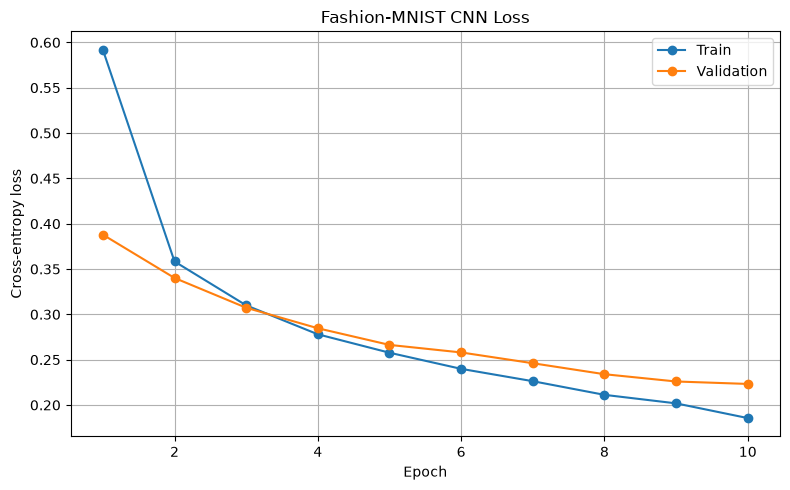

In [78]:
# train / validation の loss 曲線。validation が悪化し始めていれば過学習の兆候
figure = plt.figure(figsize=(8, 5))
axis = figure.add_subplot(1, 1, 1)

axis.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)
axis.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation",
)

axis.set_xlabel("Epoch")
axis.set_ylabel("Cross-entropy loss")
axis.set_title("Fashion-MNIST CNN Loss")
axis.grid(True)
axis.legend()

figure.tight_layout()

loss_figure_path = (
    figure_dir
    / "fashion_mnist_cnn_loss.png"
)
figure.savefig(
    loss_figure_path,
    dpi=150,
)

plt.show()


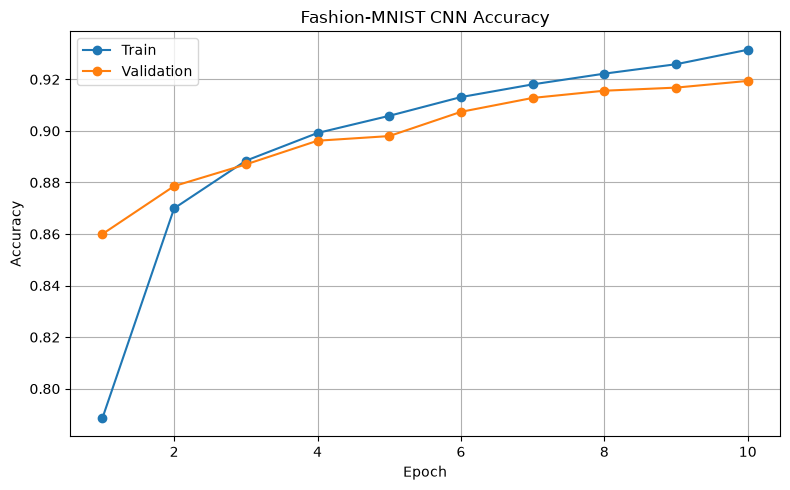

In [79]:
# train / validation の accuracy 曲線。CNN baselineが学習できているかの確認用
figure = plt.figure(figsize=(8, 5))
axis = figure.add_subplot(1, 1, 1)

axis.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train",
)
axis.plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation",
)

axis.set_xlabel("Epoch")
axis.set_ylabel("Accuracy")
axis.set_title("Fashion-MNIST CNN Accuracy")
axis.grid(True)
axis.legend()

figure.tight_layout()

accuracy_figure_path = (
    figure_dir
    / "fashion_mnist_cnn_accuracy.png"
)
figure.savefig(
    accuracy_figure_path,
    dpi=150,
)

plt.show()


## 13. Confusion Matrix

特にFashion-MNISTでは

- Shirt
- T-shirt/top
- Pullover
- Coat

あたりが混同されやすい。

SVD後にどのクラスが悪化するかを見る基準にもできる。


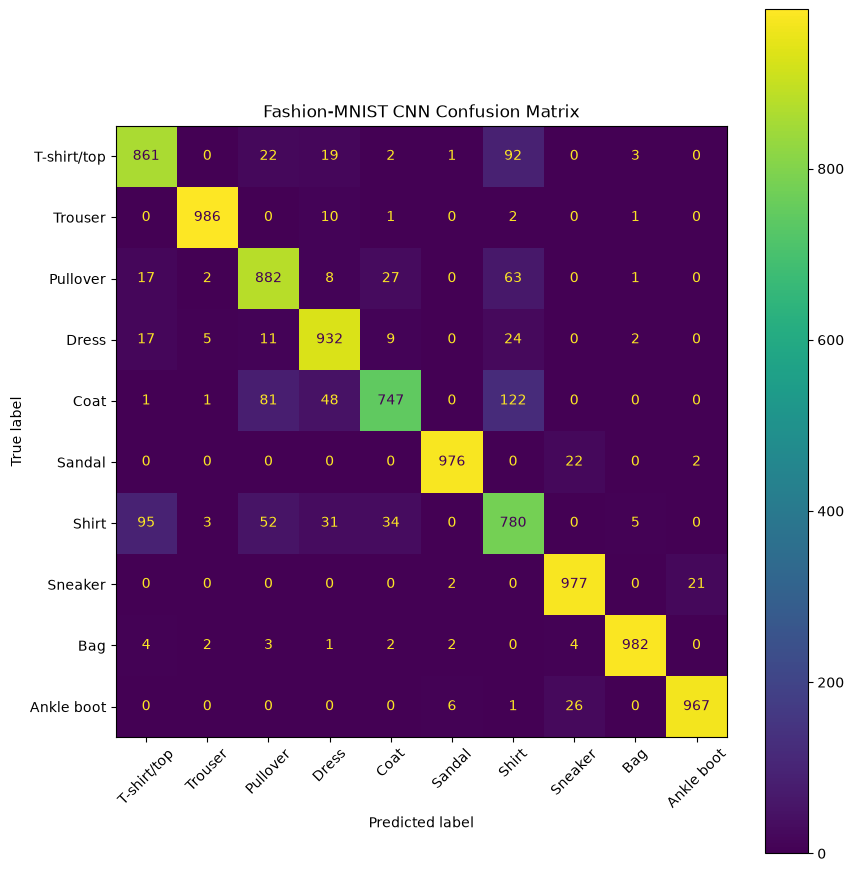

In [80]:
def predict_labels(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    """データローダ全体の正解ラベルと予測ラベルを返す。

    混同行列など、学習済みモデルの予測内容を NumPy で集計するために使う。
    重みは更新しない。戻り値はどちらも 1 次元配列で、長さはデータ件数と一致する。
    """
    # Dropout / BatchNorm がある場合に備えて推論モードへ切り替える
    model.eval()

    true_labels: list[np.ndarray] = []
    predicted_labels: list[np.ndarray] = []

    # inference_mode: 勾配不要・推論専用（no_grad より少し軽い）
    with torch.inference_mode():
        for inputs, targets in loader:
            # 入力だけ GPU へ。labels は CPU のまま NumPy 化すればよい
            inputs = inputs.to(
                device,
                non_blocking=True,  # CUDA時、転送完了を待たずに次の処理へ進める
            )

            # logits: 10クラス分の生スコア
            logits = model(inputs)
            # スコア最大のクラス番号が予測ラベル
            predictions = logits.argmax(dim=1)

            # CPU 上の ndarray として溜める（混同行列は NumPy / sklearn 向け）
            true_labels.append(
                targets.numpy()
            )
            predicted_labels.append(
                predictions.cpu().numpy()
            )

    # バッチごとの配列を 1 本に連結して返す
    return (
        np.concatenate(true_labels),
        np.concatenate(predicted_labels),
    )


# Fashion-MNIST の 10 クラス名（ラベル 0〜9 に対応）
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Test集合での予測を集め、どの服カテゴリを間違えやすいか見る
test_targets, test_predictions = predict_labels(
    model=baseline_model,
    loader=test_loader,
    device=device,
)

# confusion_matrix[i, j]: 正解がクラス i なのに j と予測した件数
matrix = confusion_matrix(
    test_targets,
    test_predictions,
)

figure, axis = plt.subplots(
    figsize=(9, 9)
)

# 数字だけでなくクラス名付きで混同行列を描く
display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=CLASS_NAMES,
)
display.plot(
    ax=axis,
    xticks_rotation=45,
    values_format="d",
)

axis.set_title(
    "Fashion-MNIST CNN Confusion Matrix"
)
figure.tight_layout()

confusion_matrix_path = (
    figure_dir
    / "fashion_mnist_cnn_confusion_matrix.png"
)
figure.savefig(
    confusion_matrix_path,
    dpi=150,
)

plt.show()


## 14. Baseline checkpoint保存

後続のSVD実験では、このcheckpointを読み込んでから圧縮する。

特に重要なのは

```text
model_state_dict
```

である。

SVD実験で毎回CNNを最初から再学習せず、**同一baseline重み**からrank比較を始める。


In [81]:
# 後続の SVD 実験で同じ baseline 重みから圧縮するため、checkpoint を残す
checkpoint_path = (
    checkpoint_dir
    / "fashion_mnist_cnn_baseline.pt"
)

# model_state_dict が本体。ほかは再現条件の記録
torch.save(
    {
        "model_class": "FashionMNISTCNN",
        "model_state_dict": baseline_model.state_dict(),
        "model_parameters": baseline_parameter_count,
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "epochs": BASELINE_EPOCHS,
        "best_epoch": best_epoch,
        "learning_rate": BASELINE_LEARNING_RATE,
        "best_validation_loss": best_validation_loss,
        "test_loss": baseline_test_loss,
        "test_accuracy": baseline_test_accuracy,
        "history": history,
        "class_names": CLASS_NAMES,
        "architecture": {
            "conv1": "Conv2d(1, 32, kernel_size=3, padding=1)",
            "pool1": "MaxPool2d(2)",
            "conv2": "Conv2d(32, 64, kernel_size=3, padding=1)",
            "pool2": "MaxPool2d(2)",
            "fc1": "Linear(3136, 128)",
            "fc2": "Linear(128, 10)",
        },
    },
    checkpoint_path,
)

# 実験条件と最終スコアの一覧（表計算ソフトでも開けるように CSV にも残す）
summary_df = pd.DataFrame(
    [
        {
            "dataset": "Fashion-MNIST",
            "model": "CNN 1-32-64 / FC 3136-128-10",
            "seed": SEED,
            "batch_size": BATCH_SIZE,
            "max_epochs": BASELINE_EPOCHS,
            "best_epoch": best_epoch,
            "optimizer": "Adam",
            "learning_rate": BASELINE_LEARNING_RATE,
            "criterion": "CrossEntropyLoss",
            "parameters": baseline_parameter_count,
            "validation_loss": best_validation_loss,
            "test_loss": baseline_test_loss,
            "test_accuracy": baseline_test_accuracy,
        }
    ]
)

summary_path = (
    csv_dir
    / "fashion_mnist_cnn_baseline_summary.csv"
)
summary_df.to_csv(
    summary_path,
    index=False,
)

# 実行環境（Python / PyTorch / OS）も含めて JSON に残す
metadata = {
    "dataset": "Fashion-MNIST",
    "transform": "ToTensor",
    "train_size": train_size,
    "validation_size": validation_size,
    "test_size": len(test_dataset),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "model": "CNN 1-32-64 / FC 3136-128-10",
    "parameters": baseline_parameter_count,
    "optimizer": "Adam",
    "learning_rate": BASELINE_LEARNING_RATE,
    "max_epochs": BASELINE_EPOCHS,
    "best_epoch": best_epoch,
    "criterion": "CrossEntropyLoss",
    "device": str(device),
    "python_version": sys.version,
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "validation_loss": best_validation_loss,
    "test_loss": baseline_test_loss,
    "test_accuracy": baseline_test_accuracy,
}

metadata_path = (
    metadata_dir
    / "fashion_mnist_cnn_baseline.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(f"checkpoint: {checkpoint_path.resolve()}")
print(f"summary:    {summary_path.resolve()}")
print(f"metadata:   {metadata_path.resolve()}")


checkpoint: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\01_cnn_baseline\fashion_mnist_cnn_baseline.pt
summary:    D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\01_cnn_baseline\fashion_mnist_cnn_baseline_summary.csv
metadata:   D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\01_cnn_baseline\fashion_mnist_cnn_baseline.json


## 15. 次のSVD実験へ進む前の確認

以下を自分で説明できれば、このNotebookは完了。

- [ ] `Conv2d(1, 32, 3, padding=1)` の意味
- [ ] なぜConv後も28×28なのか
- [ ] なぜpool後に14×14になるのか
- [ ] なぜ2回目のpool後に7×7になるのか
- [ ] なぜFlatten後が3136なのか
- [ ] `fc1.weight.shape == (128, 3136)` を確認した
- [ ] CNN baselineのvalidation loss / accuracyを記録した
- [ ] CNN baselineのtest loss / accuracyを記録した
- [ ] checkpointを保存した

次は、

```text
02_cnn_linear_svd.ipynb
```

でまず `fc1` のみをSVD低ランク化する。

Conv層のSVDはその後。
